# EDA 4 — the annotated slots, across three domains

The slots are what the experiment actually measures: a question, an attachment
and a verbatim quote from the passage. This page compares them across Swedish
statute, the constructed philosophical controls and the English RFC sections,
straight from the corpus files. No API calls.

**Every annotation here is an assistant draft with no human review.** That is
the single largest caveat on anything downstream, and it applies to every count
on this page.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from simulacria.measurement.corpus import load_corpus

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 210)
pd.set_option("display.max_colwidth", 70)

CORPORA = ["corpus/law_probe_v1.yaml", "corpus/philosophy_v1.yaml", "corpus/rfc_probe_v1.yaml"]
passages = [row for name in CORPORA for row in load_corpus(ROOT / name, ROOT)]

slots = pd.DataFrame(
    [
        {
            "domain": passage["domain"],
            "group": passage["group"],
            "passage_id": passage["passage_id"],
            "passage_chars": len(passage["text"]),
            "slot_id": slot["slot_id"],
            "kind": slot["kind"],
            "attaches_to": slot["attaches_to"],
            "question_chars": len(slot["question"]),
            "quote": slot["quote"],
            "quote_chars": len(slot["quote"]) if slot["quote"] else 0,
            "quote_start": passage["text"].find(slot["quote"]) if slot["quote"] else -1,
        }
        for passage in passages
        for slot in passage["slots"]
    ]
)
print(f"{len(passages)} passages, {len(slots)} slots, {slots.domain.nunique()} domains")

36 passages, 117 slots, 3 domains


## 1. Shape of each corpus

In [2]:
display(
    slots.groupby(["domain", "group"])
    .agg(
        passages=("passage_id", "nunique"),
        slots=("slot_id", "size"),
        slots_per_passage=("passage_id", lambda s: round(len(s) / s.nunique(), 1)),
        anchored_quotes=("quote", lambda s: int(s.notna().sum())),
        median_passage_chars=("passage_chars", "median"),
    )
    .reset_index()
)

,domain,group,passages,slots,slots_per_passage,anchored_quotes,median_passage_chars
0,inline,categorical,10,30,3.0,0,315.5
1,inline,conditional,10,30,3.0,0,319.0
2,inline,virtue,10,30,3.0,0,318.5
3,rfc,technical_norm,3,12,4.0,12,472.0
4,sfs,statutory,3,15,5.0,15,321.0


## 2. What kinds of slot exist, and what they attach to

`attaches_to` is the field that decides the sign of a direction change: a
condition on a *duty* and a condition on an *exception* move the norm opposite
ways when they disappear. The distribution below is therefore not cosmetic.

In [3]:
display(pd.crosstab(slots.kind, slots.attaches_to, margins=True))
display(pd.crosstab(slots.domain, slots.kind))
display(pd.crosstab(slots.domain, slots.attaches_to))

attaches_to,duty,exception,All
kind,,,
actor,1,0,1
condition,6,36,42
deadline,3,2,5
exception,34,0,34
modality,35,0,35
All,79,38,117


kind,actor,condition,deadline,exception,modality
domain,,,,,
inline,0,30,0,30,30
rfc,1,5,1,1,4
sfs,0,7,4,3,1


attaches_to,duty,exception
domain,,
inline,60,30
rfc,10,2
sfs,9,6


## 3. How much of a passage is actually anchored?

Quotes are the evidence a reading must reproduce. If they cover a tiny fraction
of the text, most of a rewrite is unmeasured; if they cover nearly all of it,
the slots are not selecting anything in particular.

,count,min,50%,max
domain,,,,
inline,30.0,0.000,0.000,0.000
rfc,3.0,0.374,0.650,0.913
sfs,3.0,0.620,0.685,0.750


,domain,passage_id,chars,covered_chars,coverage,slots
3,inline,virtue-01,239,0,0.0,3
6,inline,virtue-04,316,0,0.0,3
5,inline,virtue-03,262,0,0.0,3
4,inline,virtue-02,256,0,0.0,3
7,inline,virtue-05,306,0,0.0,3


,domain,passage_id,chars,covered_chars,coverage,slots
33,rfc,rfc-2119:3,263,240,0.913,4
1,sfs,sfs-1982-673:P13,603,452,0.750,6
0,sfs,sfs-2026-1281:K10P10,321,220,0.685,5
34,rfc,rfc-2119:6,472,307,0.650,4
2,sfs,sfs-1977-480:P12,276,171,0.620,4


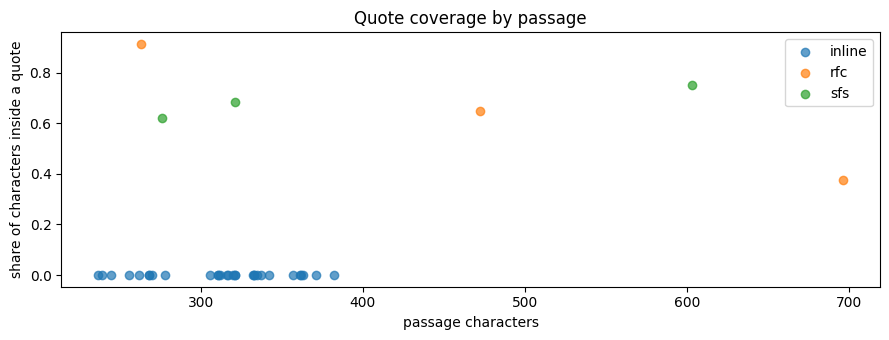

In [4]:
coverage = []
for passage in passages:
    text = passage["text"]
    covered = set()
    for slot in passage["slots"]:
        if not slot["quote"]:
            continue
        start = text.find(slot["quote"])
        covered.update(range(start, start + len(slot["quote"])))
    coverage.append(
        {
            "domain": passage["domain"],
            "passage_id": passage["passage_id"],
            "chars": len(text),
            "covered_chars": len(covered),
            "coverage": round(len(covered) / len(text), 3),
            "slots": len(passage["slots"]),
        }
    )
coverage = pd.DataFrame(coverage)
display(coverage.groupby("domain").coverage.describe()[["count", "min", "50%", "max"]].round(3))
display(coverage.sort_values("coverage").head(5))
display(coverage.sort_values("coverage", ascending=False).head(5))

fig, ax = plt.subplots(figsize=(9, 3.5))
for domain, group in coverage.groupby("domain"):
    ax.scatter(group.chars, group.coverage, label=domain, alpha=0.7)
ax.set(
    xlabel="passage characters",
    ylabel="share of characters inside a quote",
    title="Quote coverage by passage",
)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Where in the passage does each element sit?

The hypothesis under test is about *order in time* — does the condition on an
exception disappear before the exception itself. This is the order in *space*,
in the source text, which is a different thing and worth knowing first: if the
condition almost always trails its exception, then anything that truncates a
text will remove conditions first for a trivial reason.

In [5]:
anchored = slots[slots.quote_start >= 0].copy()
anchored["relative_position"] = (anchored.quote_start / anchored.passage_chars).round(3)
display(
    anchored.groupby(["domain", "attaches_to"])
    .relative_position.agg(["count", "mean", "median"])
    .round(3)
)

pairs = []
for passage in passages:
    text = passage["text"]
    exceptions = [s for s in passage["slots"] if s["kind"] == "exception" and s["quote"]]
    conditions = [
        s
        for s in passage["slots"]
        if s["attaches_to"] == "exception" and s["kind"] != "exception" and s["quote"]
    ]
    for exception in exceptions:
        for condition in conditions:
            pairs.append(
                {
                    "domain": passage["domain"],
                    "passage_id": passage["passage_id"],
                    "exception": exception["slot_id"],
                    "condition": condition["slot_id"],
                    "condition_after_exception": text.find(condition["quote"])
                    > text.find(exception["quote"]),
                }
            )
pairs = pd.DataFrame(pairs)
if len(pairs):
    display(pairs)
    print(
        f"{pairs.condition_after_exception.sum()} of {len(pairs)} condition-on-exception pairs "
        "have the condition standing after its exception in the source text."
    )
else:
    print("No condition-on-exception pairs are annotated in these corpora.")

count   mean  median
domain attaches_to                      
rfc    duty            10  0.377   0.304
       exception        2  0.742   0.742
sfs    duty             9  0.260   0.224
       exception        6  0.572   0.596

,domain,passage_id,exception,condition,condition_after_exception
0,sfs,sfs-2026-1281:K10P10,exception,exception_deadline,True
1,sfs,sfs-2026-1281:K10P10,exception,deadline_start,True
2,sfs,sfs-1982-673:P13,temporary_exception,unforeseen_event,True
3,sfs,sfs-1982-673:P13,temporary_exception,compensation,True
4,sfs,sfs-1982-673:P13,temporary_exception,night_exception,True
5,sfs,sfs-1977-480:P12,exception,special_reasons,True
6,rfc,rfc-2119:3,deviation_allowed,deviation_condition,True
7,rfc,rfc-2119:3,deviation_allowed,deviation_timing,True


8 of 8 condition-on-exception pairs have the condition standing after its exception in the source text.


## 5. Quote length — what a reader has to reproduce verbatim

A reading is rejected when its quote is not a verbatim span. Long quotes are
harder to reproduce exactly after a rewrite, so quote length partly determines
how often a slot can be confirmed at all.

In [6]:
display(anchored.groupby("domain").quote_chars.describe()[["count", "min", "50%", "max"]].round(1))
display(
    anchored.nlargest(5, "quote_chars")[["domain", "passage_id", "slot_id", "quote_chars", "quote"]]
)
print(
    "A quote spanning a line break (the RFC corpus) must be reproduced with its\n"
    "wrapping intact, which is why those spans are stored exactly as they wrap."
)

,count,min,50%,max
domain,,,,
rfc,12.0,34.0,62.5,135.0
sfs,15.0,16.0,34.0,136.0


,domain,passage_id,slot_id,quote_chars,quote
10,sfs,sfs-1982-673:P13,night_exception,136,"om arbetet med hänsyn till dess art, allmänhetens behov eller andr..."
110,rfc,rfc-2119:6,permitted_scope,135,they MUST only be used where it is\n actually required for inter...
4,sfs,sfs-2026-1281:K10P10,deadline_start,120,efter det att den systemansvariga skickat ett skriftligt ställning...
7,sfs,sfs-1982-673:P13,unforeseen_event,92,om det föranleds av något särskilt förhållande som inte har kunnat...
106,rfc,rfc-2119:3,deviation_allowed,91,there\n may exist valid reasons in particular circumstances to i...


A quote spanning a line break (the RFC corpus) must be reproduced with its
wrapping intact, which is why those spans are stored exactly as they wrap.


## 6. Questions, in the corpus's own language

Questions live in the corpus file, not in Python, so a corpus can be read in
its own language. These are the exact strings a reader model is shown.

In [7]:
for domain in sorted(slots.domain.unique()):
    sample = slots[slots.domain == domain].drop_duplicates("slot_id").head(3)
    print(f"\n--- {domain} ---")
    for _, row in sample.iterrows():
        passage = next(p for p in passages if p["passage_id"] == row.passage_id)
        question = next(s["question"] for s in passage["slots"] if s["slot_id"] == row.slot_id)
        print(f"  {row.slot_id:<24} {question}")


--- inline ---
  explicit_duty            Uttrycker texten en uttrycklig plikt eller ett förbud för en handling?
  allowed_exception        Uttrycker texten ett faktiskt tillåtet undantag från en plikt eller ett förbud? Ett påstående att undantag saknas är inte ett tillåtet undantag.
  exception_condition      Anger texten ett villkor för ett faktiskt tillåtet undantag?

--- rfc ---
  recommended_course       Does the text define a recommended course of action rather than an absolute requirement?
  deviation_allowed        Does the text allow an implementer to depart from the recommended course?
  deviation_condition      Does the text state a condition that must be met before departing from the recommendation?

--- sfs ---
  duty                     Finns en plikt att ta upp en tvist?
  scope                    Finns en avgränsning av vilka kostnader tvistprövningen avser?
  exception                Finns ett undantag från den huvudsakliga regeln?


## 7. What this means for the experiment

- The three corpora are not interchangeable: they differ in passage length,
  coverage and the mix of attachments. Results are reported per experiment and
  never pooled.
- Coverage says how much of a rewrite is even in scope for measurement.
- Spatial order (section 4) is a confounder for the temporal hypothesis, and it
  is small enough here to state explicitly rather than control for.
- None of this is evidence about model behaviour. It is the shape of the
  instrument before the instrument has been used.